# Screen Time Analysis 

<img src='https://miro.medium.com/v2/resize:fit:1400/0*7_eye6Q5nyta8Aec'>

Bu çalışmada iki sosyal medya platformu olan Whatsapp ve Instagram ekran kullanım süreleri incelenecektir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# 3 Boyutlu Veri Görselleştirme Kütüphaneleri
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
df= pd.read_csv("Screentime-App-Details.csv")

In [3]:
#EDA

In [4]:
df.head()

,Date,Usage,Notifications,Times opened,App
0,08/26/2022,38,70,49,Instagram
1,08/27/2022,39,43,48,Instagram
2,08/28/2022,64,231,55,Instagram
3,08/29/2022,14,35,23,Instagram
4,08/30/2022,3,19,5,Instagram


In [5]:
df.tail()

,Date,Usage,Notifications,Times opened,App
49,09/17/2022,212,212,120,Whatsapp
50,09/18/2022,244,303,132,Whatsapp
51,09/19/2022,77,169,105,Whatsapp
52,09/20/2022,58,190,78,Whatsapp
53,09/21/2022,89,262,68,Whatsapp


In [6]:
df.isnull().sum()

Date             0
Usage            0
Notifications    0
Times opened     0
App              0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           54 non-null     object
 1   Usage          54 non-null     int64 
 2   Notifications  54 non-null     int64 
 3   Times opened   54 non-null     int64 
 4   App            54 non-null     object
dtypes: int64(3), object(2)
memory usage: 2.2+ KB


In [8]:
df.App.value_counts()

App
Instagram    27
Whatsapp     27
Name: count, dtype: int64

In [9]:
#Feature Engineering

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

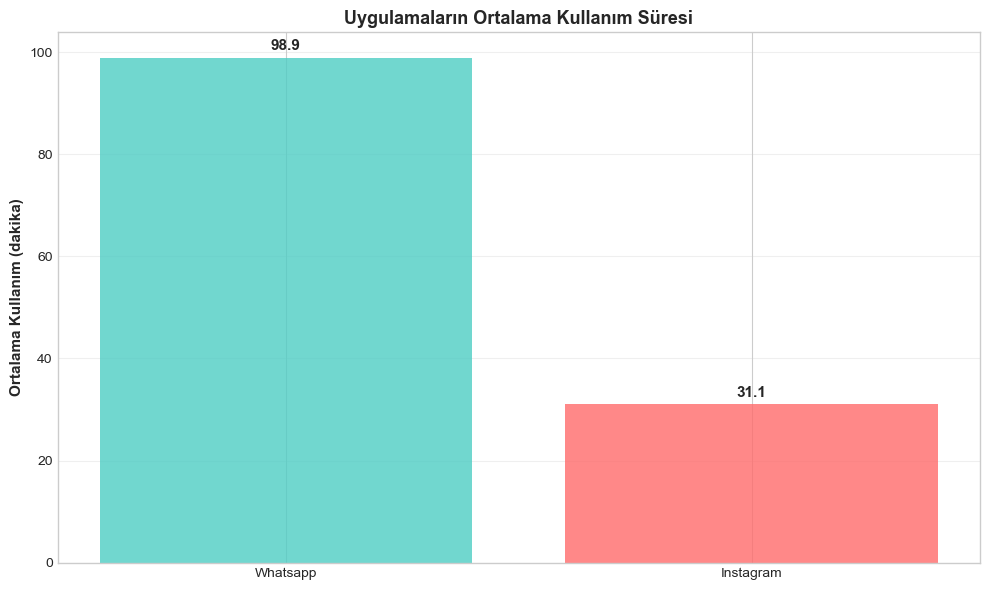

In [38]:
# Uygulamaların Ortalama Kullanım Süresi
plt.figure(figsize=(10, 6))
app_usage = df.groupby('App')['Usage'].mean().sort_values(ascending=False)
colors = ['#4ECDC4', '#FF6B6B'][:len(app_usage)]  
bars = plt.bar(
    app_usage.index,
    app_usage.values,
    color=colors,
    linewidth=2,
    alpha=0.8
)
plt.bar_label(bars, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')
plt.ylabel('Ortalama Kullanım (dakika)', fontsize=11, fontweight='bold')
plt.title('Uygulamaların Ortalama Kullanım Süresi', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

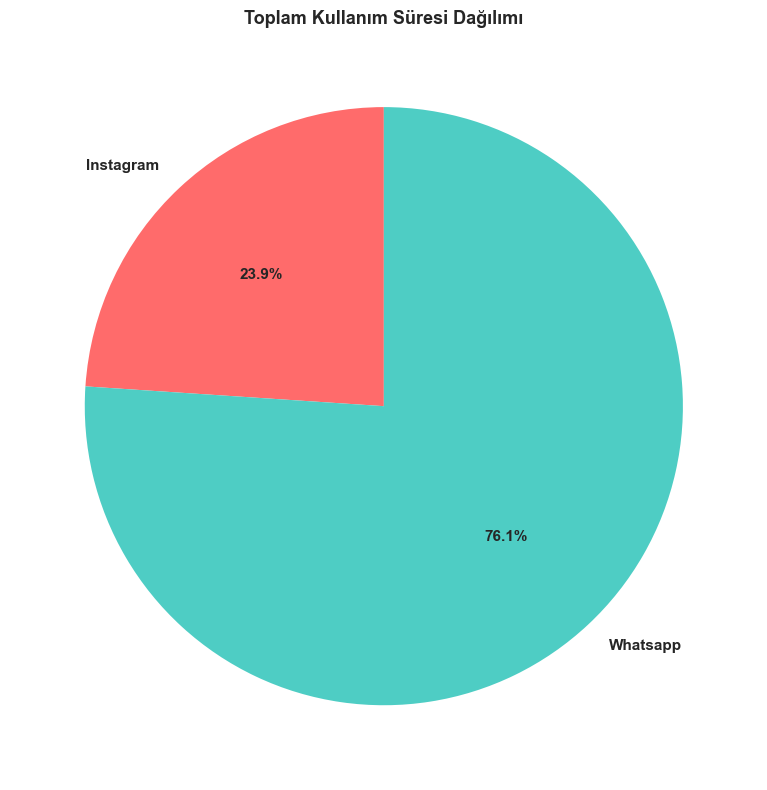

In [39]:
# Toplam Kullanım Oranları
plt.figure(figsize=(10, 8))
app_total = df.groupby('App')['Usage'].sum()
colors = ['#FF6B6B', '#4ECDC4'][:len(app_total)]
plt.pie(
    app_total.values,
    labels=app_total.index,
    autopct='%.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
plt.title('Toplam Kullanım Süresi Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Her iki uygulamanın ortalama ve toplam kullanım oranları incelendğinde Whatsapp'ın Instagram'a kıyasla oldukça yüksek bir orana sahip olduğu görülmektedir.

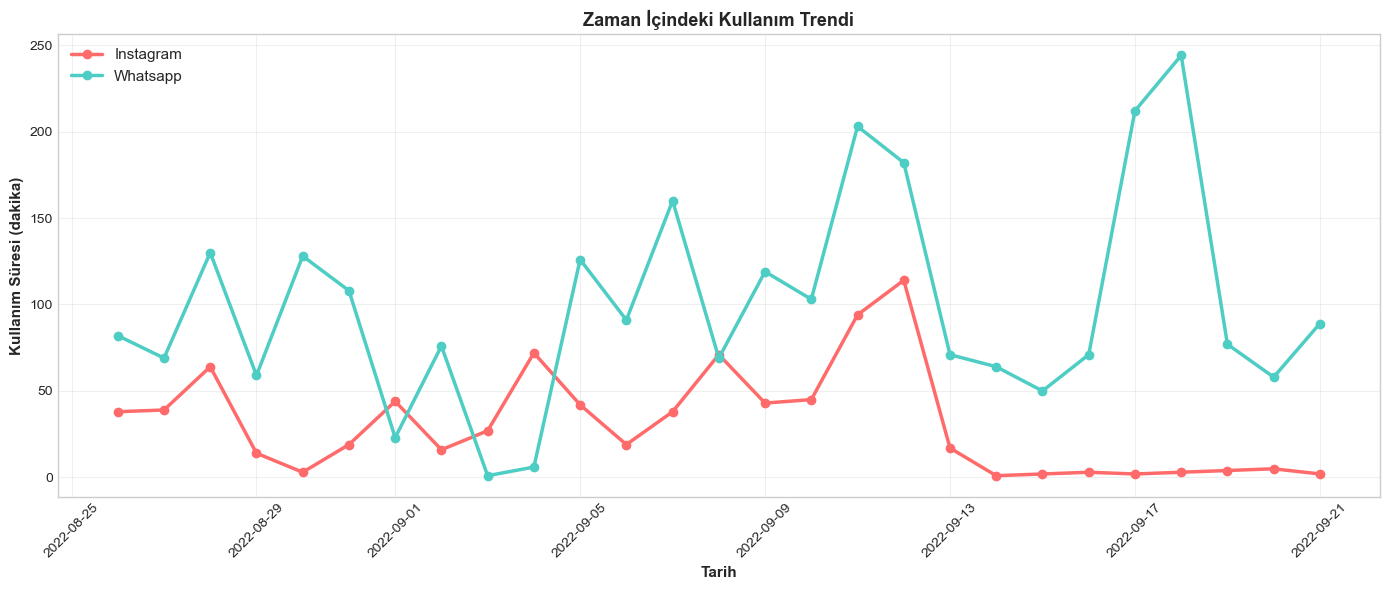

In [15]:
# Zaman İçindeki Kullanım Trendi
plt.figure(figsize=(14, 6))
for app in df['App'].unique():
    app_data = df[df['App'] == app].sort_values('Date')
    color = '#FF6B6B' if app == 'Instagram' else '#4ECDC4'
    plt.plot(app_data['Date'], app_data['Usage'], marker='o', label=app, 
            linewidth=2.5, markersize=6, color=color)
plt.xlabel('Tarih', fontsize=11, fontweight='bold')
plt.ylabel('Kullanım Süresi (dakika)', fontsize=11, fontweight='bold')
plt.title('Zaman İçindeki Kullanım Trendi', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafik incelendiğinde, WhatsApp kullanımının genel olarak Instagram’a göre daha yüksek olduğu ve daha dalgalı bir seyir izlediği görülmektedir. Bazı günlerde WhatsApp kullanım süresi 200 dakikanın üzerine çıkarak zirve yaparken, zaman zaman belirgin düşüşler de yaşanmaktadır. Instagram ise çoğunlukla daha düşük seviyelerde ve daha dengeli bir kullanım göstermektedir. Eylül ortasında her iki uygulamada da artış dikkat çekmekte, özellikle Instagram bu dönemde en yüksek seviyesine ulaşmaktadır. Dönemin sonuna doğru Instagram kullanımında belirgin bir azalma gözlenmektedir. Genel olarak, kullanıcının WhatsApp’ı daha yoğun ve öncelikli kullandığı söylenebilir.

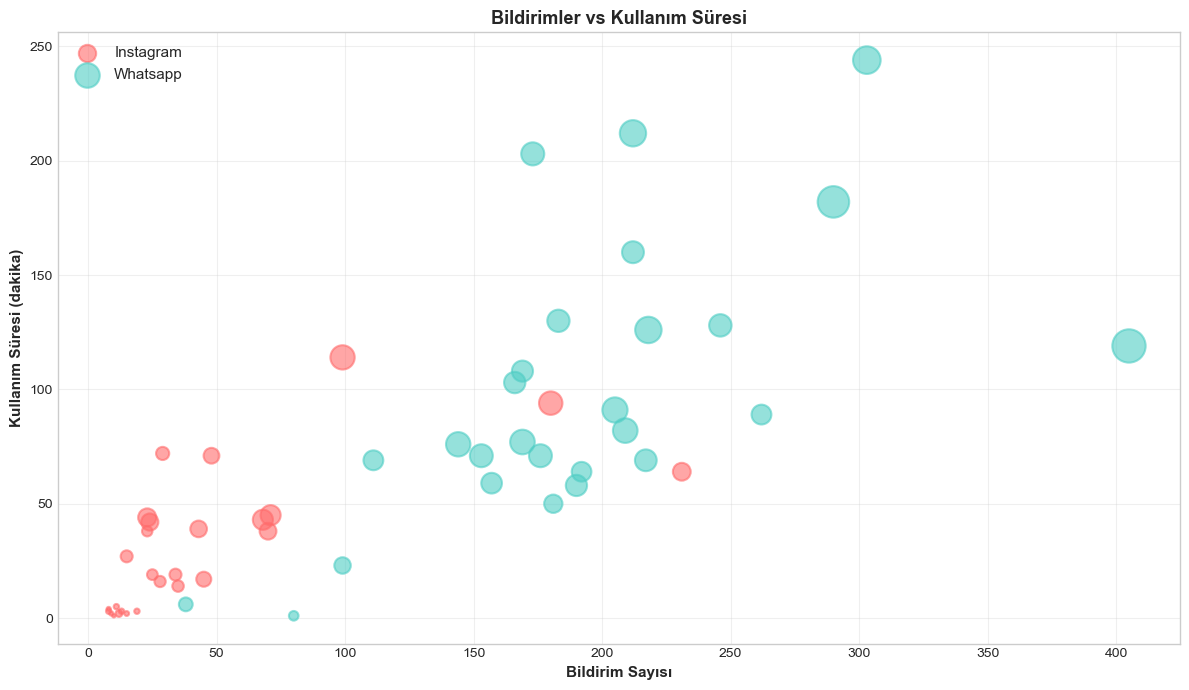

In [40]:
#  BUBBLE CHART - Notifications vs Usage
plt.figure(figsize=(12, 7))
colors_map = {'Instagram': '#FF6B6B', 'Whatsapp': '#4ECDC4'}
for app in df['App'].unique():
    app_data = df[df['App'] == app]
    plt.scatter(app_data['Notifications'], app_data['Usage'], 
               s=app_data['Times opened']*3, alpha=0.6, label=app,
               color=colors_map.get(app, '#000000'), linewidth=1.5)
plt.xlabel('Bildirim Sayısı', fontsize=11, fontweight='bold')
plt.ylabel('Kullanım Süresi (dakika)', fontsize=11, fontweight='bold')
plt.title('Bildirimler vs Kullanım Süresi', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, scatterpoints=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

WhatsApp’ta bildirim sayısı arttıkça kullanım süresi de ciddi şekilde yükselmektedir. Buna karşılık Instagram’da değerler daha düşük ve daha dar bir aralıkta yoğunlaşırken, kullanım süresi bildirimlerden kısmen bağımsız görünmekteidr. Bu durum, WhatsApp’ın daha çok anlık iletişime bağlı kullanılan bir uygulama iken Instagram’ın ise alışkanlık ve içerik tüketimi odaklı olan bir uygulama olmasıyla da ilişkilidir.

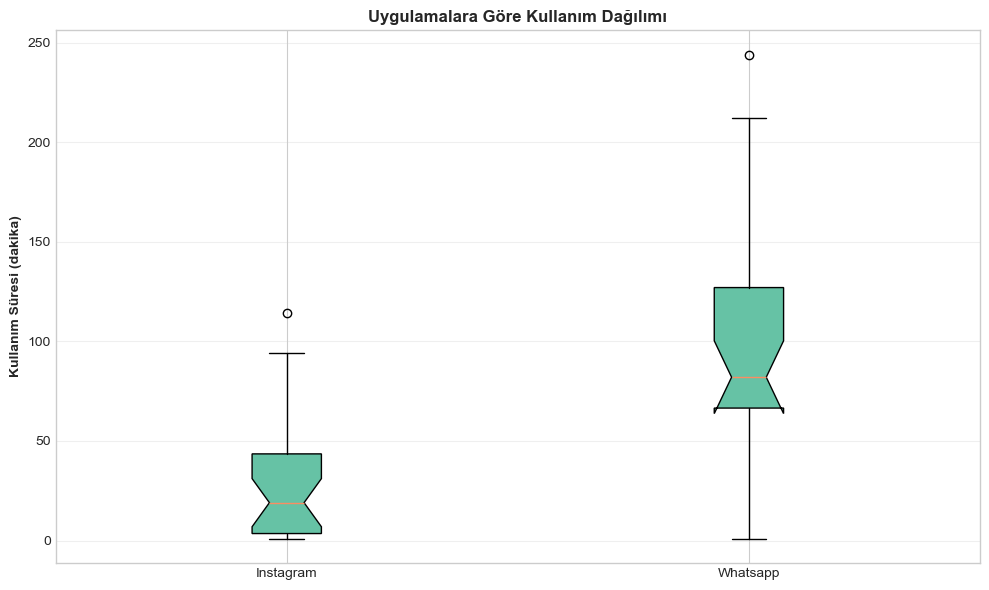

In [22]:
# Uygulamalara Göre Kullanım Dağılımı
apps = df['App'].unique()
data = [df.loc[df['App']==a, 'Usage'].values for a in apps]
plt.figure(figsize=(10,6))
bp = plt.boxplot(data, labels=apps, patch_artist=True, notch=True)
plt.ylabel('Kullanım Süresi (dakika)', fontweight='bold')
plt.title('Uygulamalara Göre Kullanım Dağılımı', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

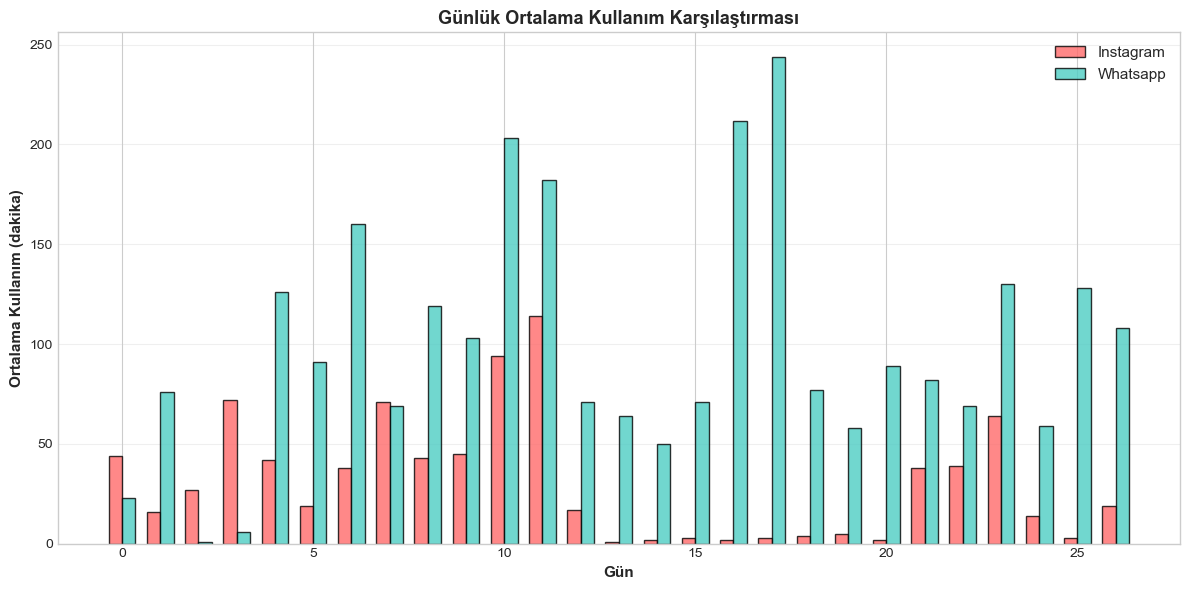

In [23]:
# Günlük Ortalama Karşılaştırması
plt.figure(figsize=(12, 6))
df['Day'] = df['Date'].dt.day
day_app = df.groupby(['Day', 'App'])['Usage'].mean().unstack()
x = np.arange(len(day_app.index))
width = 0.35
bars1 = plt.bar(x - width/2, day_app['Instagram'], width, label='Instagram', color='#FF6B6B', alpha=0.8, edgecolor='black')
bars2 = plt.bar(x + width/2, day_app['Whatsapp'], width, label='Whatsapp', color='#4ECDC4', alpha=0.8, edgecolor='black')
plt.xlabel('Gün', fontsize=11, fontweight='bold')
plt.ylabel('Ortalama Kullanım (dakika)', fontsize=11, fontweight='bold')
plt.title('Günlük Ortalama Kullanım Karşılaştırması', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

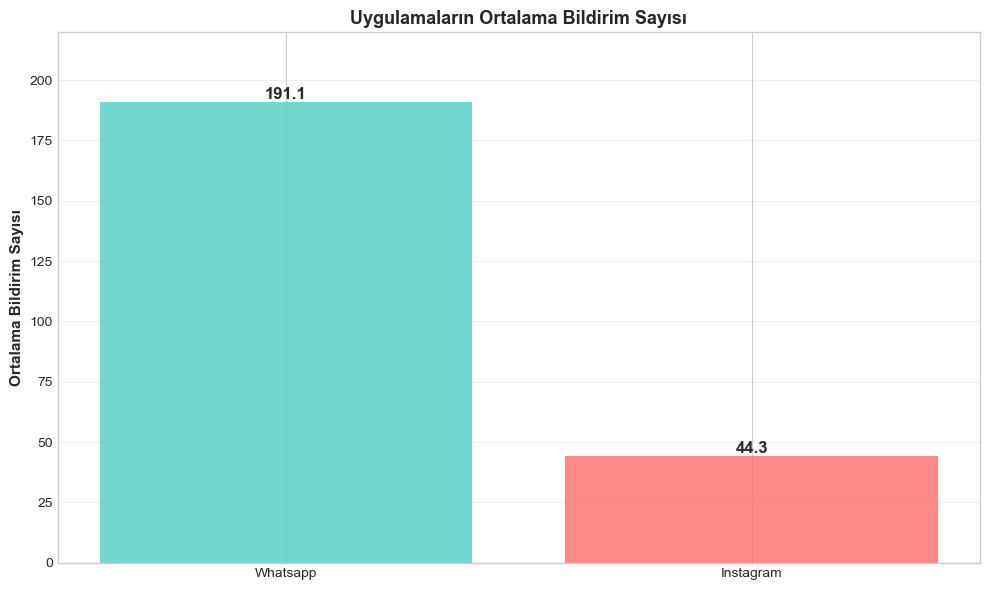

In [34]:
#  Bildirim Ortalaması Karşılaştırması
plt.figure(figsize=(10, 6))
app_notif = df.groupby('App')['Notifications'].mean().sort_values(ascending=False)
colors = ['#4ECDC4', '#FF6B6B'] if app_notif.index[0] == 'Whatsapp' else ['#FF6B6B', '#4ECDC4']
bars = plt.bar(app_notif.index, app_notif.values, color=colors, linewidth=2, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylabel('Ortalama Bildirim Sayısı', fontsize=11, fontweight='bold')
plt.title('Uygulamaların Ortalama Bildirim Sayısı', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(app_notif.values) * 1.15)
plt.tight_layout()
plt.show()

Ortalama bildirim sayısının WhatsApp için 191, Instagram için ise 44 olması, WhatsApp’ın anlık mesajlaşma ile sık bildirim alınmasını gerektiren yapıya sahip bir uygulama olmasından da kaynaklanmaktadır. Instagram’da bildirimlerin daha sınırlı kalması, kullanımın daha çok kullanıcının uygulamayı kullanma alışkanlıkları ile ilgili olmaktadır.

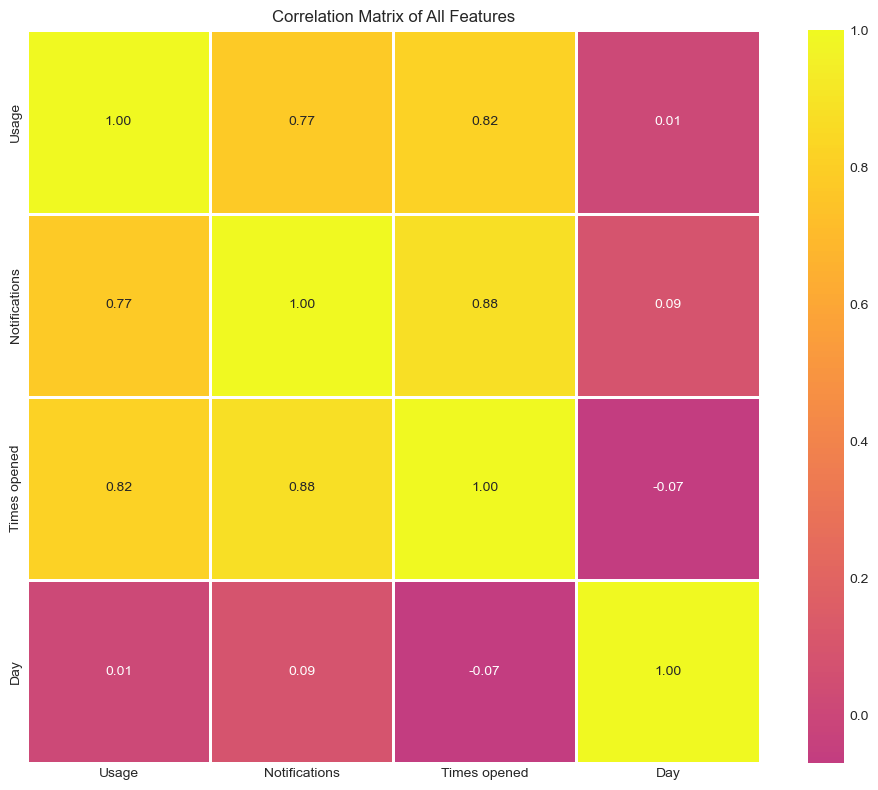

In [32]:
#HEATMAP - Korelasyon Matrisi
correlation_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='plasma', center=0,fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

Kullanım süresi, bildirim sayısı ve uygulamanın açılma sayısı arasında güçlü ve pozitif ilişkiler olduğu görülmektedir (0.77–0.88 arası) yani bildirimler ve açılma sıklığı arttıkça kullanım süresi de artma eğilimindedir.

In [17]:
# Özet İstatistikler
print("=" * 60)
print("📊 EKRAN SÜRESİ ANALİZİ ÖZET İSTATİSTİKLERİ")
print("=" * 60)
for app in df['App'].unique():
    app_data = df[df['App'] == app]
    print(f"\n{app.upper()}:")
    print(f"  📱 Veri Sayısı: {len(app_data)}")
    print(f"  ⏱️ Ortalama Kullanım: {app_data['Usage'].mean():.1f} dakika")
    print(f"  📈 Max Kullanım: {app_data['Usage'].max()} dakika")
    print(f"  📉 Min Kullanım: {app_data['Usage'].min()} dakika")
    print(f"  🔔 Ortalama Bildirim: {app_data['Notifications'].mean():.1f}")
    print(f"  🔓 Ortalama Açılış: {app_data['Times opened'].mean():.1f}")

📊 EKRAN SÜRESİ ANALİZİ ÖZET İSTATİSTİKLERİ

INSTAGRAM:
  📱 Veri Sayısı: 27
  ⏱️ Ortalama Kullanım: 31.1 dakika
  📈 Max Kullanım: 114 dakika
  📉 Min Kullanım: 1 dakika
  🔔 Ortalama Bildirim: 44.3
  🔓 Ortalama Açılış: 32.7

WHATSAPP:
  📱 Veri Sayısı: 27
  ⏱️ Ortalama Kullanım: 98.9 dakika
  📈 Max Kullanım: 244 dakika
  📉 Min Kullanım: 1 dakika
  🔔 Ortalama Bildirim: 191.1
  🔓 Ortalama Açılış: 90.3


Bu çalışmada WhatsApp ve Instagram için 27 günlük veri üzerinden kullanım süresi, bildirim sayısı ve uygulama açılma sıklığı analiz edilmiştir. Elde edilen sonuçlar, WhatsApp’ın ortalama 98.9 dakika kullanım, 191 bildirim ve 90 açılış ile Instagram’a kıyasla çok daha yoğun kullanıldığını göstermektedir. Ayrıca her iki uygulamada da bildirim ve açılma sayısı arttıkça kullanım süresinin yükseldiği gözlemlenmiş, ancak bu ilişkinin WhatsApp’ta daha güçlü olduğu sonucuna ulaşılmıştır.